# EcoSIM Kernel Case Study: Structured Surrogate for Soil Decomposition

This notebook demonstrates the core Trusty Neurocoder idea on an **EcoSIM-style kernel**:

- isolate one repeated scientific update rule
- preserve the known scientific scaffold
- learn only the uncertain subfunctions
- verify simple invariants after training

The kernel we model is a simplified soil decomposition update:

```python
decay_fast = k_fast * f_theta(moisture) * state.fast
decay_slow = k_slow * temp_response(temp) * state.slow
```

where the **pool-to-pool transfer structure** is fixed, while the environmental response functions are learned from data.

This is not a full EcoSIM integration. It is a concrete, notebook-friendly approximation of the kind of kernel Trusty Neurocoder is targeting.

## Scientific Structure

We treat the following parts as **known**:

- four solid carbon pools: protein, carbohydrate, cellulose, lignin
- one dissolved organic matter pool (`C_DOM`)
- Monod-style substrate limitation
- product inhibition by dissolved organic carbon
- mass-conserving transfer from solid pools to DOM

We treat the following parts as **unknown and learnable**:

- temperature response `f_temp(T)`
- water stress response `f_water(PSI)`

The learning signal here comes from **simulator-generated trajectories** using a hidden ground-truth kernel.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyReal
from cajal.compiling import compile, TypedTensor

matplotlib.rcParams['figure.dpi'] = 120
device = torch.device('cpu')
torch.manual_seed(0)

# Known structure / parameters
K_PROT = 1.0
K_CARB = 1.0
K_CELL = 0.2
K_LIGN = 0.067
K_RATES = torch.tensor([K_PROT, K_CARB, K_CELL, K_LIGN], device=device)

KM_SUBSTRATE = 0.5
KI_DOM = 2.0
DT = 0.5
N_STEPS = 10

C0_PROT = 0.15
C0_CARB = 0.30
C0_CELL = 0.35
C0_LIGN = 0.15
C0_DOM = 0.05

RGASC = 8.3143

# 3 x 3 training grid
TEMPERATURES = torch.linspace(278.0, 308.0, 3, device=device)
WATER_POTENTIALS = torch.linspace(-400.0, -10.0, 3, device=device)


In [2]:
def true_tsens_growth(T):
    """EcoSIM-like Arrhenius temperature response."""
    T = float(T)
    rtk = RGASC * T
    stk = 710.0 * T
    actv = 1.0 + torch.exp(torch.tensor((197500.0 - stk) / rtk)) + \
                  torch.exp(torch.tensor((stk - 222500.0) / rtk))
    return (torch.exp(torch.tensor(25.229 - 62500.0 / rtk)) / actv).item()


def true_wat_stress(psi):
    """EcoSIM-like water stress response."""
    psi = float(psi)
    return torch.exp(torch.tensor(0.2 * max(psi, -500.0))).item()


def generate_trajectories():
    conditions = []
    curves = []

    for T in TEMPERATURES:
        for PSI in WATER_POTENTIALS:
            f_env = true_tsens_growth(T) * true_wat_stress(PSI)
            curve = []
            c_prot, c_carb, c_cell, c_lign, c_dom = (
                C0_PROT, C0_CARB, C0_CELL, C0_LIGN, C0_DOM
            )

            for _ in range(N_STEPS):
                curve.append(torch.tensor([c_prot, c_carb, c_cell, c_lign, c_dom]))

                c_total = c_prot + c_carb + c_cell + c_lign
                dfns = c_total / (c_total + KM_SUBSTRATE) if c_total > 1e-12 else 0.0
                oqci = 1.0 / (1.0 + c_dom / KI_DOM)
                env_factor = f_env * dfns * oqci

                d_prot = K_PROT * env_factor * c_prot * DT
                d_carb = K_CARB * env_factor * c_carb * DT
                d_cell = K_CELL * env_factor * c_cell * DT
                d_lign = K_LIGN * env_factor * c_lign * DT

                c_prot -= d_prot
                c_carb -= d_carb
                c_cell -= d_cell
                c_lign -= d_lign
                c_dom += d_prot + d_carb + d_cell + d_lign

            conditions.append((T.item(), PSI.item()))
            curves.append(torch.stack(curve))

    return conditions, curves


conditions, true_curves = generate_trajectories()
N_TRAJ = len(conditions)
conditions

[(278.0, -400.0),
 (278.0, -205.0),
 (278.0, -10.0),
 (293.0, -400.0),
 (293.0, -205.0),
 (293.0, -10.0),
 (308.0, -400.0),
 (308.0, -205.0),
 (308.0, -10.0)]

In [3]:
class TempResponseMLP(nn.Module):
    """Positive temperature response."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 16), nn.Tanh(),
            nn.Linear(16, 1), nn.Softplus(),
        )

    def forward(self, T):
        T_norm = (T - 278.0) / 30.0
        return self.net(T_norm.view(1, 1)).squeeze()


class WaterStressMLP(nn.Module):
    """Water response constrained to [0, 1]."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.Tanh(),
            nn.Linear(16, 16), nn.Tanh(),
            nn.Linear(16, 1), nn.Sigmoid(),
        )

    def forward(self, PSI):
        PSI_norm = (PSI + 400.0) / 400.0
        return self.net(PSI_norm.view(1, 1)).squeeze()


class EcoSIMDecompUpdate(nn.Module):
    """One structured, mass-conserving kernel update."""
    def __init__(self, k_rates, km, ki, dt, f_temp_mlp, f_water_mlp):
        super().__init__()
        self.k_rates = k_rates
        self.km = km
        self.ki = ki
        self.dt = dt
        self.f_temp = f_temp_mlp
        self.f_water = f_water_mlp

    def forward(self, state):
        c_prot = state.data[0]
        c_carb = state.data[1]
        c_cell = state.data[2]
        c_lign = state.data[3]
        c_dom = state.data[4]
        T = state.data[5]
        PSI = state.data[6]

        f_env = self.f_temp(T) * self.f_water(PSI)
        c_total = c_prot + c_carb + c_cell + c_lign
        dfns = c_total / (c_total + self.km)
        oqci = 1.0 / (1.0 + c_dom / self.ki)
        rate_mod = f_env * dfns * oqci

        d_prot = self.k_rates[0] * rate_mod * c_prot * self.dt
        d_carb = self.k_rates[1] * rate_mod * c_carb * self.dt
        d_cell = self.k_rates[2] * rate_mod * c_cell * self.dt
        d_lign = self.k_rates[3] * rate_mod * c_lign * self.dt

        c_prot_new = c_prot - d_prot
        c_carb_new = c_carb - d_carb
        c_cell_new = c_cell - d_cell
        c_lign_new = c_lign - d_lign
        c_dom_new = c_dom + d_prot + d_carb + d_cell + d_lign

        return TypedTensor(
            torch.stack([c_prot_new, c_carb_new, c_cell_new, c_lign_new, c_dom_new, T, PSI]),
            state.ty,
        )


program = TmIter(TmVar('s0'), 's', TmApp(TmVar('f'), TmVar('s')), TmVar('n'))
compiled = compile(program)

f_temp_mlp = TempResponseMLP()
f_water_mlp = WaterStressMLP()
update_fn = EcoSIMDecompUpdate(K_RATES, KM_SUBSTRATE, KI_DOM, DT, f_temp_mlp, f_water_mlp)
optimizer = torch.optim.Adam(list(f_temp_mlp.parameters()) + list(f_water_mlp.parameters()), lr=0.005)


In [4]:
losses = []

for epoch in range(80):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)

    for traj_idx in range(N_TRAJ):
        T_val, PSI_val = conditions[traj_idx]
        s0 = TypedTensor(
            torch.tensor([C0_PROT, C0_CARB, C0_CELL, C0_LIGN, C0_DOM, T_val, PSI_val]),
            TyReal(7),
        )

        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            result = compiled({
                's0': s0,
                'f': lambda s, _fn=update_fn: _fn(s),
                'n': TypedTensor(n_onehot, TyNat()),
            })
            predicted = result.data[:5]
            truth = true_curves[traj_idx][step]
            total_loss = total_loss + ((predicted - truth) ** 2).sum()

    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())

    if epoch % 20 == 0 or epoch == 79:
        print(f'epoch {epoch:3d}  loss={total_loss.item():.6f}')


epoch   0  loss=7.137815


epoch  20  loss=0.421031


epoch  40  loss=0.372703


epoch  60  loss=0.338323


epoch  79  loss=0.279274


In [5]:
T_test = torch.linspace(275.0, 315.0, 50)
PSI_test = torch.linspace(-450.0, -5.0, 50)

with torch.no_grad():
    true_temp = [true_tsens_growth(T) for T in T_test]
    learned_temp = [f_temp_mlp(T).item() for T in T_test]
    true_water = [true_wat_stress(PSI) for PSI in PSI_test]
    learned_water = [f_water_mlp(PSI).item() for PSI in PSI_test]

all_positive = True
mass_conserved = True
initial_total = C0_PROT + C0_CARB + C0_CELL + C0_LIGN + C0_DOM

with torch.no_grad():
    for traj_idx in range(N_TRAJ):
        T_val, PSI_val = conditions[traj_idx]
        s0 = TypedTensor(
            torch.tensor([C0_PROT, C0_CARB, C0_CELL, C0_LIGN, C0_DOM, T_val, PSI_val]),
            TyReal(7),
        )
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            result = compiled({
                's0': s0,
                'f': lambda s, _fn=update_fn: _fn(s),
                'n': TypedTensor(n_onehot, TyNat()),
            })
            pools = result.data[:5]
            all_positive = all_positive and not (pools < -1e-9).any().item()
            mass_conserved = mass_conserved and abs(pools.sum().item() - initial_total) <= 1e-5

print(f'final loss: {losses[-1]:.6f}')
print(f'all pools non-negative: {all_positive}')
print(f'mass conserved across 5 pools: {mass_conserved}')


final loss: 0.279274
all pools non-negative: True
mass conserved across 5 pools: True


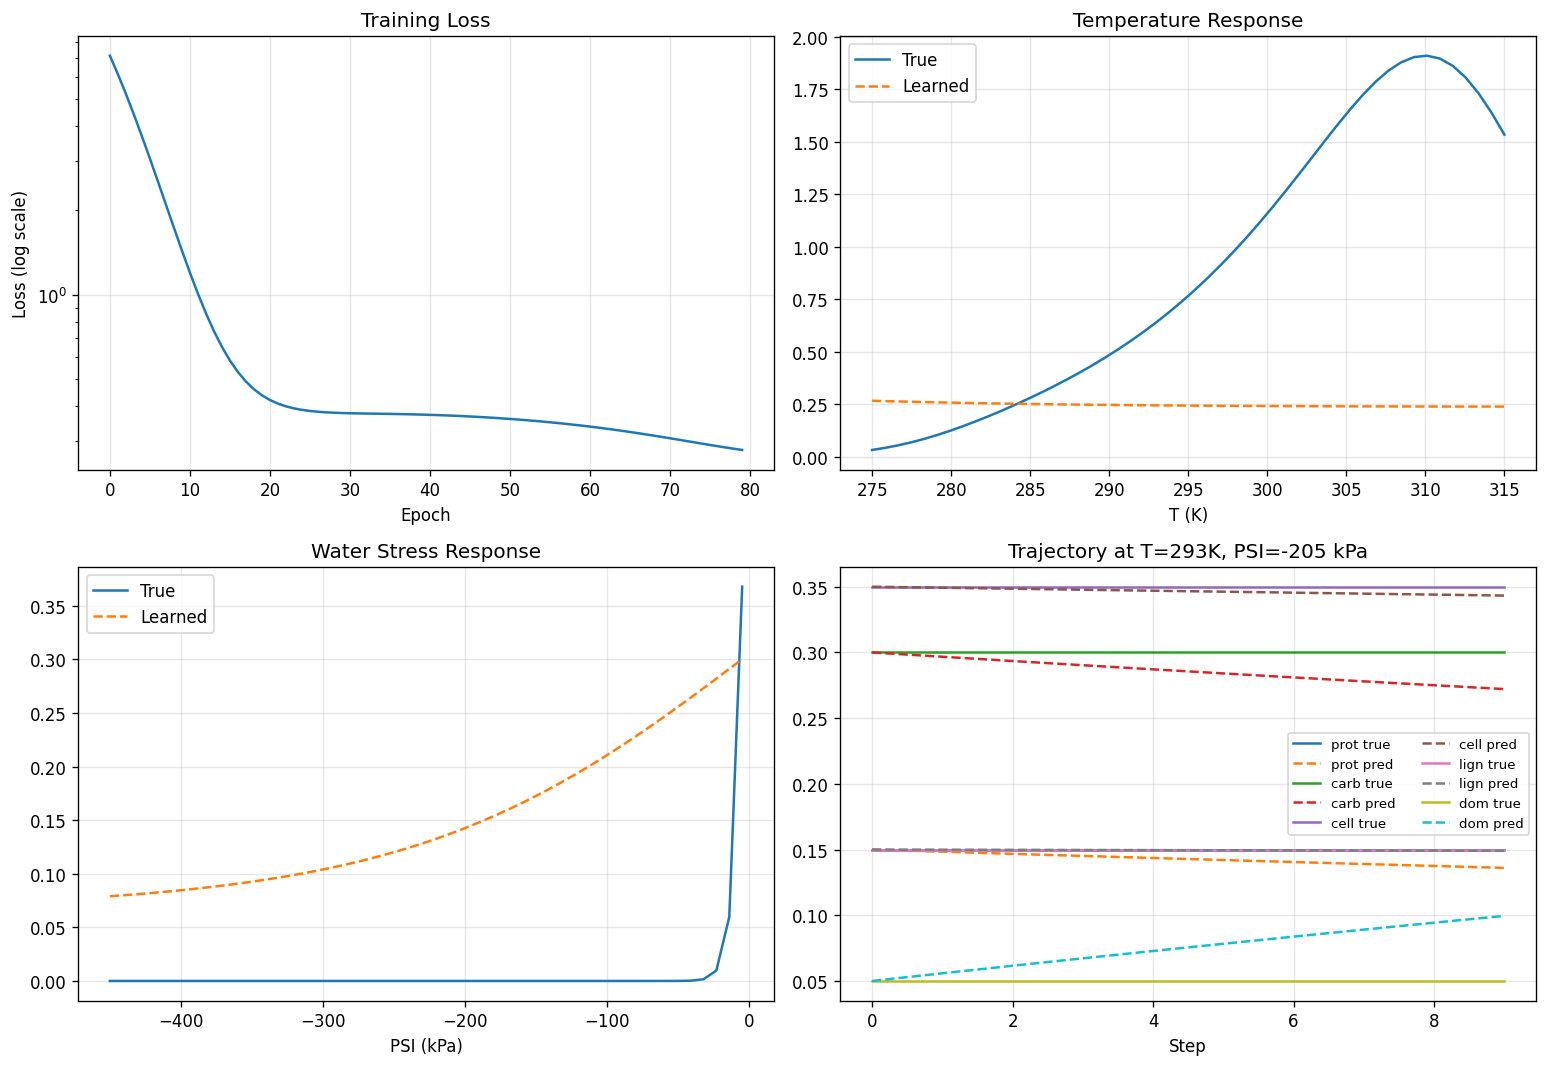

In [6]:
ref_idx = 4  # middle condition in the 3x3 grid
T_val, PSI_val = conditions[ref_idx]
s0 = TypedTensor(torch.tensor([C0_PROT, C0_CARB, C0_CELL, C0_LIGN, C0_DOM, T_val, PSI_val]), TyReal(7))

pred_traj = []
with torch.no_grad():
    for step in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS)
        n_onehot[step] = 1.0
        result = compiled({
            's0': s0,
            'f': lambda s, _fn=update_fn: _fn(s),
            'n': TypedTensor(n_onehot, TyNat()),
        })
        pred_traj.append(result.data[:5])

pred_traj = torch.stack(pred_traj)
true_traj = true_curves[ref_idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].semilogy(losses)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log scale)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(T_test.numpy(), true_temp, label='True')
axes[0, 1].plot(T_test.numpy(), learned_temp, '--', label='Learned')
axes[0, 1].set_title('Temperature Response')
axes[0, 1].set_xlabel('T (K)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(PSI_test.numpy(), true_water, label='True')
axes[1, 0].plot(PSI_test.numpy(), learned_water, '--', label='Learned')
axes[1, 0].set_title('Water Stress Response')
axes[1, 0].set_xlabel('PSI (kPa)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

pool_names = ['prot', 'carb', 'cell', 'lign', 'dom']
for i, name in enumerate(pool_names):
    axes[1, 1].plot(true_traj[:, i].numpy(), label=f'{name} true')
    axes[1, 1].plot(pred_traj[:, i].numpy(), '--', label=f'{name} pred')
axes[1, 1].set_title(f'Trajectory at T={T_val:.0f}K, PSI={PSI_val:.0f} kPa')
axes[1, 1].set_xlabel('Step')
axes[1, 1].legend(ncol=2, fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Takeaway

This notebook shows the intended value proposition in concrete form:

- the **kernel boundary** is explicit
- the **scientific scaffold** stays fixed
- only the uncertain response functions are learned
- training can use **simulator traces** as supervision
- simple invariants like **mass conservation** remain checkable

That is the main distinction from a pure black-box surrogate.